In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
import json

kaggle_creds = {"username": "maria303","key": "3e509e67e40b697ccdd34ecf8762dc0b"}

# Сохраняем в файл
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

!chmod 600 ~/.kaggle/kaggle.json

print("\nДатасеты:")
!kaggle datasets list --mine

# Имя датасета
dataset_name = "maria303/dl-lab-1-image-classification"
print(f"\nСкачиваем {dataset_name}")

# Скачиваем датасет
!kaggle datasets download -d {dataset_name} --force

import os
import glob
zip_files = glob.glob("*.zip")
print(f"\nНайдены zip файлы: {zip_files}")

if zip_files:
    zip_file = zip_files[0]
    print(f"Разархивируем {zip_file}...")
    !unzip -o -q "{zip_file}" -d ./my_dataset

    # Устанавливаем path точно так же, как в оригинальном коде
    path = "./my_dataset"
    print(f"Путь к данным: {path}")

    # Сохраняем path в переменную окружения, чтобы была доступна в других ячейках
    %store path

    # Проверяем структуру для оригинального кода
    data_folder = os.path.join(path, 'dl-lab-1-image-classification — наш')
    print(f"\nПроверка структуры для ячейки 6:")
    print(f"Содержимое data_folder: {os.listdir(data_folder)}")

    # Проверяем путь, который будет использован в ячейке 6
    dataset_path = os.path.join(data_folder, 'train', 'train')
    print(f"Путь: {dataset_path}")
    print(f"Существует: {os.path.exists(dataset_path)}")

    if os.path.exists(dataset_path):
        print("Готово")
    else:
        print("Путь не существует, проверьте структуру")
else:
    print("Zip файл не найден")


Датасеты:
ref                                     title                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------  ---------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
maria303/dl-lab-1-image-classification  dl-lab-1-image-classification-new   203919330  2026-02-17 18:10:38.620000            101          0  0.11764706       

Скачиваем maria303/dl-lab-1-image-classification
Dataset URL: https://www.kaggle.com/datasets/maria303/dl-lab-1-image-classification
License(s): unknown
 76% 148M/194M [00:00<00:00, 1.55GB/s]
100% 194M/194M [00:00<00:00, 1.00GB/s]

Найдены zip файлы: ['dl-lab-1-image-classification.zip']
Разархивируем dl-lab-1-image-classification.zip...
Путь к данным: ./my_dataset
Stored 'path' (str)

Проверка структуры для ячейки 6:
Содержимое data_folder: ['train.csv', 'test.csv', 'sample_submission.csv', 'train', 'test

In [ ]:
import albumentations as A
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import os
import random
from collections import defaultdict
from glob import glob

In [ ]:
# фиксация всех сидов
SEED = 2026

import os
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# для скорости и качества
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

In [ ]:
# заготовка под data loader

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)


In [ ]:
class_to_idx = { "Апельсин": 0, "Бананы": 1, "Груши": 2, "Кабачки": 3, "Капуста": 4, "Картофель": 5, "Киви": 6, "Лимон": 7, "Лук": 8, "Мандарины": 9, "Морковь": 10, "Огурцы": 11, "Томаты": 12, "Яблоки зелёные": 13, "Яблоки красные": 14 }

In [ ]:
class MyDataset(Dataset):
    def __init__(self, images_filepaths, name2label, transform=None):
        self.images_filepaths = images_filepaths
        self.transform = transform
        self.name2label = name2label

    def __len__(self):
        return len(self.images_filepaths)

    def __getitem__(self, idx):
        image_filepath = self.images_filepaths[idx]

        # читаем изображение, всегда 3 канала (BGR)
        data = np.fromfile(image_filepath, dtype=np.uint8)
        image = cv2.imdecode(data, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        #/Класс/Подкласс/файл.jpg
        class_name = os.path.basename(os.path.dirname(os.path.dirname(image_filepath)))
        label = self.name2label[class_name]

        if self.transform is not None:
            image = self.transform(image=image)['image']

        return image, label


def train_test_split_from_directory(root_path, folder2class=None, train_size=0.8, seed=9999):
    train, test = [], []
    rng = random.Random(seed)

    # Проходим по основным классам (сортируем для воспроизводимости)
    for class_name in sorted(os.listdir(root_path)):
        class_path = os.path.join(root_path, class_name)
        if not os.path.isdir(class_path):
            continue

        # Проходим по подклассам (сортируем для воспроизводимости)
        for subclass_name in sorted(os.listdir(class_path)):
            subclass_path = os.path.join(class_path, subclass_name)
            if not os.path.isdir(subclass_path):
                continue

            # Собираем изображения
            images = (
                glob(os.path.join(subclass_path, '*.jpg')) +
                glob(os.path.join(subclass_path, '*.png')) +
                glob(os.path.join(subclass_path, '*.jpeg'))
            )

            if len(images) == 0:
                continue

            # Перемешиваем изображения в подклассе (локальный rng)
            rng.shuffle(images)

            # Разбиение для каждого подкласса отдельно
            split_idx = int(train_size * len(images))
            train.extend(images[:split_idx])
            test.extend(images[split_idx:])

    return train, test


In [ ]:
%store -r path
data_folder = os.path.join(path, 'dl-lab-1-image-classification — наш')
dataset_path = os.path.join(data_folder, 'train', 'train')

train, test = train_test_split_from_directory(
    root_path=dataset_path,
    train_size=0.8,
    seed=SEED
)

print(f"Тренировочных: {len(train)}, Тестовых: {len(test)}")


Тренировочных: 7868, Тестовых: 1991


# Посмотрим на распределение данных

In [ ]:
from collections import Counter
import os

def count_classes(image_paths, class_to_idx):
    counts = Counter()
    for image_path in image_paths:
        # класс = папка на 2 уровня выше
        class_name = os.path.basename(
            os.path.dirname(
                os.path.dirname(image_path)
            )
        )
        class_idx = class_to_idx[class_name]
        counts[class_idx] += 1
    return counts


train_counts = count_classes(train, class_to_idx)
test_counts  = count_classes(test, class_to_idx)

print("Train distribution:", train_counts)
print("Test distribution:", test_counts)

Train distribution: Counter({0: 691, 13: 670, 4: 667, 1: 642, 5: 631, 9: 627, 12: 609, 14: 574, 7: 544, 8: 530, 10: 496, 11: 476, 2: 324, 3: 237, 6: 150})
Test distribution: Counter({0: 175, 13: 172, 4: 169, 1: 162, 5: 160, 9: 159, 12: 153, 14: 147, 7: 136, 8: 135, 10: 124, 11: 119, 2: 82, 3: 60, 6: 38})


In [ ]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(class_to_idx)

# собираем количество примеров по порядку классов 0..14
class_counts = np.array([train_counts[i] for i in range(num_classes)])

# веса обратно пропорциональны количеству
class_weights = 1.0 / class_counts

# нормализация (чтобы средний вес был ≈1)
class_weights = class_weights * (num_classes / class_weights.sum())

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)


Class weights: tensor([0.6315, 0.6797, 1.3468, 1.8412, 0.6542, 0.6915, 2.9091, 0.8021, 0.8233,
        0.6960, 0.8798, 0.9167, 0.7165, 0.6513, 0.7602], device='cuda:0')


loss_fn

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

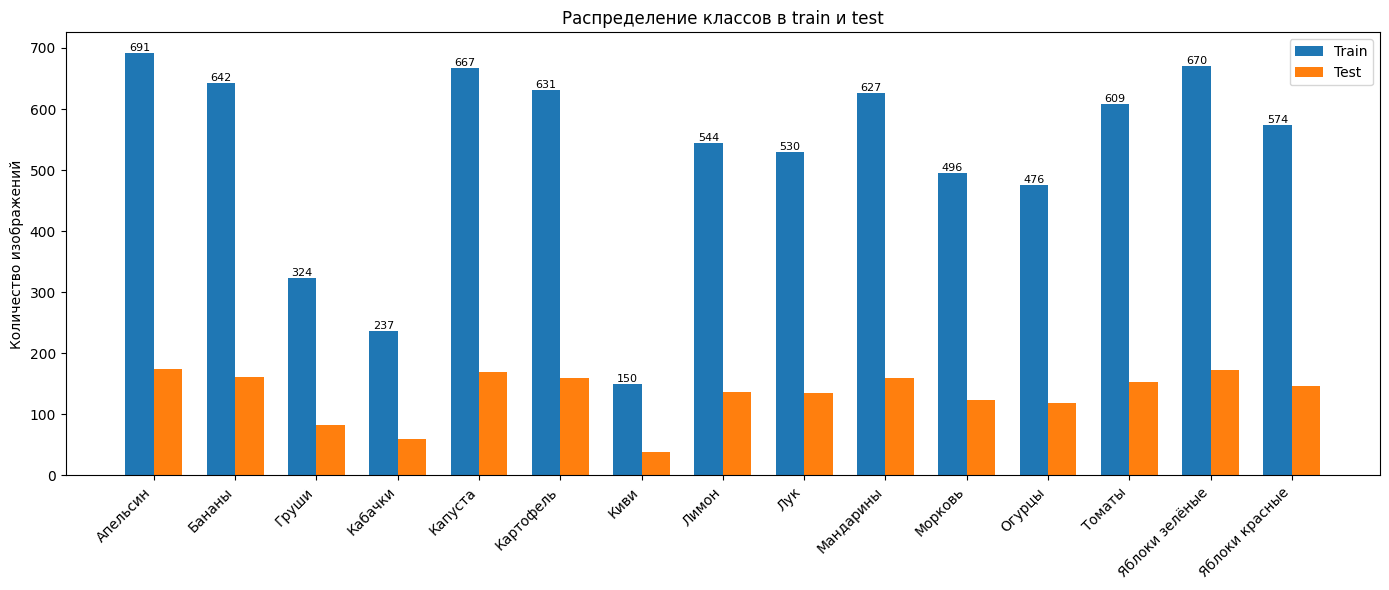

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# порядок 0..14
classes = sorted(class_to_idx.values())
idx2class = {v: k for k, v in class_to_idx.items()}
class_names = [idx2class[i] for i in classes]

train_values = [train_counts.get(i, 0) for i in classes]
test_values  = [test_counts.get(i, 0) for i in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(14, 6))

bars1 = plt.bar(x - width/2, train_values, width, label='Train')
bars2 = plt.bar(x + width/2, test_values,  width, label='Test')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в train и test')
plt.legend()

# подписи значений
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

rows = []

for class_idx, class_name in idx2class.items():
    train_cnt = train_counts.get(class_idx, 0)
    test_cnt  = test_counts.get(class_idx, 0)
    total     = train_cnt + test_cnt

    test_ratio = test_cnt / total if total > 0 else 0

    rows.append({
        "Класс": class_name,
        "Train": train_cnt,
        "Test": test_cnt,
        "Total": total,
        "Test %": round(test_ratio * 100, 2)
    })

df = pd.DataFrame(rows)
df

,Класс,Train,Test,Total,Test %
0,Апельсин,691,175,866,20.21
1,Бананы,642,162,804,20.15
2,Груши,324,82,406,20.20
3,Кабачки,237,60,297,20.20
4,Капуста,667,169,836,20.22
5,Картофель,631,160,791,20.23
6,Киви,150,38,188,20.21
7,Лимон,544,136,680,20.00
8,Лук,530,135,665,20.30
9,Мандарины,627,159,786,20.23


# Вернёмся к обучению

убрали дубли GaussNoise/Blur/RandomBrightnessContrast

сделали Rotate мягче

добавили RandomResizedCrop (это прям важно для 97%)

оставили шум/блюр, но редко и выборочно

In [ ]:
train_transforms = A.Compose([
    A.RandomResizedCrop(size=(300, 300), scale=(0.65, 1.0), ratio=(0.75, 1.33), p=1.0),

    A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.12, rotate_limit=15, p=0.4, border_mode=cv2.BORDER_REFLECT_101),

    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=12, p=0.3),

    # A.ColorJitter(
    #     brightness=0.15,
    #     contrast=0.15,
    #     saturation=0.15,
    #     hue=0.03,
    #     p=0.7
    # ),

    A.OneOf([
        A.GaussNoise(std_range=(0.01, 0.05), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.2),

    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    A.ToTensorV2(),
])
val_transforms = A.Compose([
    A.Resize(300, 300),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    A.ToTensorV2(),
])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
train_dataset = MyDataset(images_filepaths=train, name2label=class_to_idx, transform=train_transforms)
val_dataset   = MyDataset(images_filepaths=test,  name2label=class_to_idx, transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=g
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("logs")

In [ ]:
def train(
    model,
    loss_fn,
    optimizer,
    train_loader,
    val_loader,
    device,
    writer=None,
    n_epoch=3,
    best_model_path='best_model.pth',
    scheduler=None,
    use_amp=True,
    grad_clip=1.0
):
    best_val_acc = 0.0
    best_val_loss = float('inf')
    num_iter = 0

    amp_enabled = (use_amp and device.type == "cuda")
    if amp_enabled:
        from torch.amp import autocast, GradScaler
        scaler = GradScaler("cuda")
    else:
        scaler = None
        autocast = None

    for epoch in range(1, n_epoch + 1):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epoch}", leave=True)

        for X_batch, y_batch in pbar:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if amp_enabled:
                with autocast(device_type="cuda", dtype=torch.float16):
                    logits = model(X_batch)
                    loss = loss_fn(logits, y_batch)

                scaler.scale(loss).backward()
                # clip in fp32 space
                scaler.unscale_(optimizer)
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(X_batch)
                loss = loss_fn(logits, y_batch)
                loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            bs = y_batch.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            y_pred = logits.argmax(dim=1)
            total_correct += (y_pred == y_batch).sum().item()

            avg_loss = total_loss / max(total_samples, 1)
            acc = total_correct / max(total_samples, 1)

            pbar.set_postfix(train_loss=f"{avg_loss:.4f}", train_acc=f"{acc:.4f}")

            num_iter += 1
            if writer is not None:
                writer.add_scalar("Loss/train", loss.item(), num_iter)
                writer.add_scalar("Accuracy/train", (y_pred == y_batch).float().mean().item(), num_iter)

        # валидация
        val_acc, val_loss = evaluate(model, val_loader, loss_fn, device, desc=f"Val {epoch}/{n_epoch}")

        if scheduler is not None:
            scheduler.step()

        if writer is not None:
            writer.add_scalar("Loss/val", val_loss, epoch)
            writer.add_scalar("Accuracy/val", val_acc, epoch)

        print(f"Epoch {epoch}/{n_epoch}: val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        # сохраняется лучшая модель
        is_better = (
            (val_acc > best_val_acc) or
            (val_acc == best_val_acc and val_loss < best_val_loss)
        )

        if is_better:
            best_val_acc = val_acc
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Сохранена лучшая модель: val_acc={best_val_acc:.4f}")

    # load best weights back
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    return model


## Три основные составляющие любого обучения:
### 1) Модель
### 2) Функция ошибок (loss function)
### 3) Оптимизатор

In [ ]:
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=15)
model.to(device)

# функция потерь с весами классов + сглаживание
loss_fn = torch.nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# оптимизатор AdamW (лучше для ConvNeXt)
learning_rate = 3e-4
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=0.05
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [ ]:
# scheduler создаём внутри K-Fold
# чтобы он был привязан к optimizer каждого фолда
best_model_path = 'best_model.pth'

from torch.optim.lr_scheduler import CosineAnnealingLR

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=10,      # столько же, сколько эпох
    eta_min=1e-6   # чтобы lr не упал в 0
)


In [ ]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device, desc="Val"):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    pbar = tqdm(dataloader, desc=desc, leave=False)
    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        y_pred = logits.argmax(dim=1)
        total_correct += (y_pred == y_batch).sum().item()
        total_samples += batch_size

        avg_loss = total_loss / max(total_samples, 1)
        acc = total_correct / max(total_samples, 1)
        pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{acc:.4f}")

    avg_loss = total_loss / max(total_samples, 1)
    accuracy = total_correct / max(total_samples, 1)
    return accuracy, avg_loss

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
from tqdm import tqdm
from torch.optim.lr_scheduler import CosineAnnealingLR

#Создаем списки файлов
train_paths, test_paths = train_test_split_from_directory(
    root_path=dataset_path,
    train_size=0.8,
    seed=SEED
)

print(f"Тренировочных: {len(train_paths)}")

#Создаем метки для K-Fold
all_paths = train_paths
all_labels = []
for path in all_paths:
    class_name = os.path.basename(os.path.dirname(os.path.dirname(path)))
    all_labels.append(class_to_idx[class_name])

print(f"Всего изображений для K-Fold: {len(all_paths)}")

#K-Fold
n_folds = 3
n_classes = 15
n_epoch = 10 # 5 обычно мало, чтобы пробить 0.97
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

fold_models = []  # для сохранения моделей
fold_scores = []  # для сохранения метрик

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\nFOLD {fold + 1}/{n_folds}")

    #пути текущего фолда
    train_paths_fold = [all_paths[i] for i in train_idx]
    val_paths_fold = [all_paths[i] for i in val_idx]
    print(f"Тренировочных: {len(train_paths_fold)}, Валидационных: {len(val_paths_fold)}")

    #веса классов СТРОГО по train этого фолда
    y_train = np.array(all_labels)[train_idx]
    counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
    inv = 1.0 / np.clip(counts, 1.0, None)
    inv = inv * (n_classes / inv.sum())
    class_weights_fold = torch.tensor(inv, dtype=torch.float32, device=device)

    #модель (простая голова обычно лучше, чем 2 слоя)
    model = timm.create_model(
        "efficientnet_b3",
        pretrained=True,
        num_classes=n_classes,
        drop_rate=0.3,
    ).to(device)

    #оптимизатор
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.02)

    #scheduler создаём внутри фолда, чтобы был привязан к optimizer
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epoch, eta_min=1e-6)

    #loss
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_fold, label_smoothing=0.05)

    # DataLoader для этого фолда
    train_dataset = MyDataset(train_paths_fold, class_to_idx, train_transforms)
    val_dataset = MyDataset(val_paths_fold, class_to_idx, val_transforms)

    train_loader = DataLoader(
        train_dataset,
        batch_size=24,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        worker_init_fn=seed_worker,
        generator=g
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        worker_init_fn=seed_worker,
        generator=g
    )

    # Путь для сохранения модели этого фолда
    best_model_path = f"best_model_fold_{fold}.pth"

    # ОБУЧАЕМ
    model = train(
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        writer=writer,
        n_epoch=n_epoch,
        scheduler=scheduler,
        best_model_path=best_model_path,
        use_amp=True,
        grad_clip=1.0
    )

    fold_models.append(model)

    val_acc, val_loss = evaluate(model, val_loader, loss_fn, device)
    fold_scores.append(val_acc)
    print(f"Fold {fold + 1} финальная val_acc: {val_acc:.4f}")

print(f"\n{'='*50}")
print(f"РЕЗУЛЬТАТЫ K-FOLD:")
print(f"{'='*50}")
print(f"Средняя точность: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Моделей в ансамбле: {len(fold_models)}")


Тренировочных: 7868
Всего изображений для K-Fold: 7868

FOLD 1/3
Тренировочных: 5245, Валидационных: 2623


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1/10:   0%|          | 0/219 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_ratio

Epoch 1/10: val_loss=0.8111  val_acc=0.8658
✅ Сохранена лучшая модель: val_acc=0.8658


Epoch 2/10: 100%|██████████| 219/219 [00:55<00:00,  3.91it/s, train_acc=0.8580, train_loss=0.8156]


Epoch 2/10: val_loss=0.7213  val_acc=0.8952
✅ Сохранена лучшая модель: val_acc=0.8952


...

Epoch 9/10: 100%|██████████| 219/219 [00:54<00:00,  4.00it/s, train_acc=0.9956, train_loss=0.3957]


Epoch 9/10: val_loss=0.5878  val_acc=0.9382


Epoch 10/10: 100%|██████████| 219/219 [00:58<00:00,  3.74it/s, train_acc=0.9975, train_loss=0.3932]


Epoch 10/10: val_loss=0.5959  val_acc=0.9348


Fold 3 финальная val_acc: 0.9397

РЕЗУЛЬТАТЫ K-FOLD:
Средняя точность: 0.9404 ± 0.0021
Моделей в ансамбле: 3


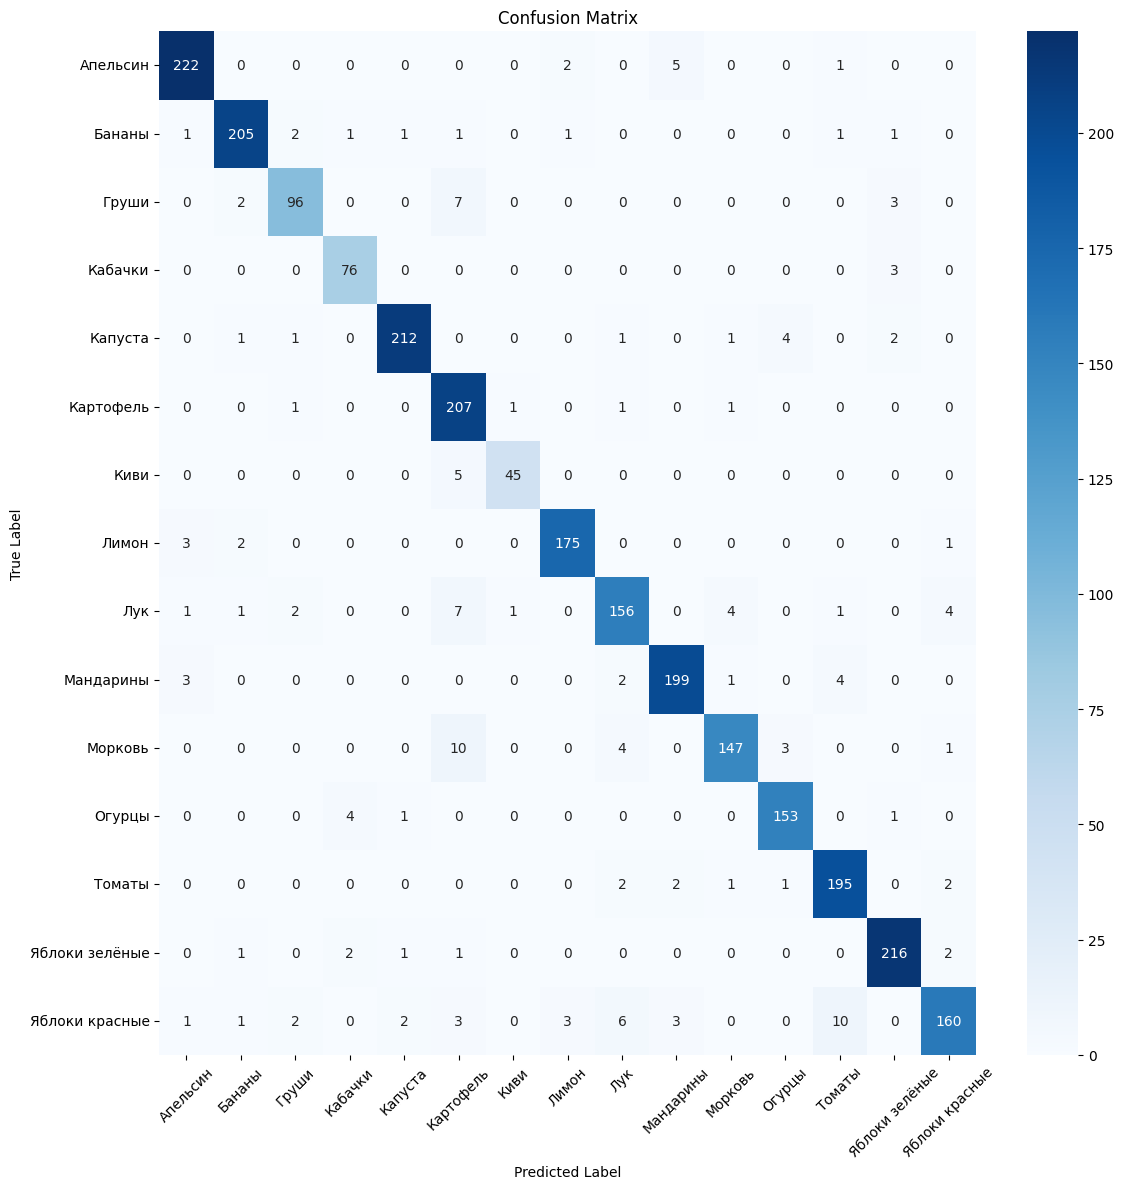

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in val_loader:  # используем test_loader
        X = X.to(device)
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.numpy())
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Посмотрим на итоговые метрики

In [ ]:
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix

@torch.no_grad()
def sklearn_report(model, dataloader, device, idx2class=None, digits=4):
    model.eval()

    y_true, y_pred = [], []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_pred.append(preds)
        y_true.append(y_batch.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # names for report
    if idx2class is None:
        target_names = None
        labels = None
    else:
        labels = sorted(idx2class.keys())
        target_names = [idx2class[i] for i in labels]

    rep = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=digits,
        zero_division=0
    )
    print(rep)

In [ ]:
sklearn_report(model, val_loader, device, idx2class=idx2class)

                precision    recall  f1-score   support

      Апельсин     0.9610    0.9652    0.9631       230
        Бананы     0.9624    0.9579    0.9602       214
         Груши     0.9231    0.8889    0.9057       108
       Кабачки     0.9157    0.9620    0.9383        79
       Капуста     0.9770    0.9550    0.9658       222
     Картофель     0.8589    0.9810    0.9159       211
          Киви     0.9574    0.9000    0.9278        50
         Лимон     0.9669    0.9669    0.9669       181
           Лук     0.9070    0.8814    0.8940       177
     Мандарины     0.9522    0.9522    0.9522       209
       Морковь     0.9484    0.8909    0.9187       165
        Огурцы     0.9503    0.9623    0.9563       159
        Томаты     0.9198    0.9606    0.9398       203
Яблоки зелёные     0.9558    0.9686    0.9621       223
Яблоки красные     0.9412    0.8377    0.8864       191

      accuracy                         0.9397      2622
     macro avg     0.9398    0.9354    0.9369 

# Оформляем предсказание

In [ ]:
# Пути к тестовым данным и сабмишену
data_folder = os.path.join(path, 'dl-lab-1-image-classification — наш')
test_images_dir = os.path.join(data_folder, 'test_images', 'test_images')
submission_path = os.path.join(data_folder, 'sample_submission.csv')
output_path = "submission.csv"

print(f"Путь к тестовым изображениям: {test_images_dir}")
print(f"Путь к sample_submission.csv: {submission_path}")
print(f"Файл существует: {os.path.exists(submission_path)}")

Путь к тестовым изображениям: ./my_dataset/dl-lab-1-image-classification — наш/train/train/Яблоки красные/807/dececd5f96d94085b1e824cd92c386df.jpg/dl-lab-1-image-classification — наш/test_images/test_images
Путь к sample_submission.csv: ./my_dataset/dl-lab-1-image-classification — наш/train/train/Яблоки красные/807/dececd5f96d94085b1e824cd92c386df.jpg/dl-lab-1-image-classification — наш/sample_submission.csv
Файл существует: False


In [ ]:
# ОПТИМИЗАЦИЯ ВЕСОВ ЧЕРЕЗ CatBoost

!pip install catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

print("\n" + "="*50)
print("ОПТИМИЗАЦИЯ ВЕСОВ ЧЕРЕЗ CatBoost")
print("="*50)

# Собираем предсказания на валидации
val_dataset_full = MyDataset(test_paths, class_to_idx, val_transforms)
val_loader_full = DataLoader(
    val_dataset_full,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

all_model_probs_val = []
true_labels_val = []

for model_idx, fold_model in enumerate(fold_models):
    fold_model.eval()
    model_probs_val = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(val_loader_full, desc=f"Модель {model_idx} на валидации"):
            X_batch = X_batch.to(device)
            probs = torch.softmax(fold_model(X_batch), dim=1)
            model_probs_val.append(probs.cpu().numpy())

            if model_idx == 0:
                true_labels_val.extend(y_batch.numpy())

    all_model_probs_val.append(np.vstack(model_probs_val))

true_labels_val = np.array(true_labels_val)
n_models = len(fold_models)
n_classes = 15
n_samples = len(true_labels_val)

print(f"Собрано предсказаний: {n_samples} образцов, {n_models} моделей")

# Создаём признаки для CatBoost
X_catboost = []
for i in range(n_samples):
    sample_features = []
    for model_idx in range(n_models):
        sample_features.extend(all_model_probs_val[model_idx][i])
    X_catboost.append(sample_features)

X_catboost = np.array(X_catboost)
y_catboost = true_labels_val

# Разделяем на train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_catboost, y_catboost, test_size=0.2, random_state=42, stratify=y_catboost
)

# Обучаем CatBoost
cb_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiClass',
    verbose=False,
    random_seed=42
)

cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)

# Получаем важность признаков
feature_importance = cb_model.get_feature_importance()
cb_weights = []
for model_idx in range(n_models):
    start_idx = model_idx * n_classes
    end_idx = (model_idx + 1) * n_classes
    model_importance = np.sum(feature_importance[start_idx:end_idx])
    cb_weights.append(model_importance)

# Нормализуем
cb_weights = np.array(cb_weights)
cb_weights = cb_weights / cb_weights.sum() * len(cb_weights)

print(f"\nВеса от CatBoost: {[f'{w:.4f}' for w in cb_weights]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



ОПТИМИЗАЦИЯ ВЕСОВ ЧЕРЕЗ CatBoost


Модель 0 на валидации:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Модель 2 на валидации: 100%|██████████| 32/32 [00:11<00:00,  2.67it/s]


Собрано предсказаний: 1991 образцов, 3 моделей


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

#SIMPLE & SAFE ENSEMBLE INFERENCE (2-TTA: identity + hflip)

submission = pd.read_csv(submission_path)
image_ids = submission["image_id"].tolist()
print(f"Загружено {len(image_ids)} изображений из sample_submission.csv")

class TestDataset(Dataset):
    def __init__(self, image_ids, images_dir, transforms=None):
        self.image_ids = image_ids
        self.images_dir = images_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.images_dir, image_id)

        # np.fromfile
        img = cv2.imdecode(np.fromfile(image_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        if img is None:
            # если вдруг файл битый/не читается
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms is not None:
            img = self.transforms(image=img)["image"]
        return img

test_ds = TestDataset(image_ids, test_images_dir, transforms=val_transforms)
test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# модели в eval
for m in fold_models:
    m.eval()

#веса ансамбля: лучше начать с fold_scores или равных весов
if "fold_scores" in globals() and len(fold_scores) == len(fold_models):
    w = np.array(fold_scores, dtype=np.float32)
else:
    w = np.ones(len(fold_models), dtype=np.float32)

w = w / (w.sum() + 1e-12)
weights = torch.tensor(w, device=device)
print("Веса ансамбля:", [f"{x:.4f}" for x in w], "sum=", float(w.sum()))

pred_labels = []

with torch.inference_mode():
    for batch in tqdm(test_loader, desc="Predicting (ensemble + 2-TTA)"):
        batch = batch.to(device, non_blocking=True)

        # 2-TTA: original + horizontal flip
        batch_hflip = torch.flip(batch, dims=[3])

        # суммарные вероятности
        ens_probs = None

        for i, m in enumerate(fold_models):
            logits1 = m(batch)
            logits2 = m(batch_hflip)

            probs = (torch.softmax(logits1, dim=1) + torch.softmax(logits2, dim=1)) / 2.0
            probs = probs * weights[i]

            ens_probs = probs if ens_probs is None else (ens_probs + probs)

        preds = ens_probs.argmax(dim=1).detach().cpu().numpy().tolist()
        pred_labels.extend(preds)

assert len(pred_labels) == len(submission), (len(pred_labels), len(submission))
submission["label"] = pred_labels
out_path = "submission_ens_tta2.csv"
submission.to_csv(out_path, index=False)
print("✅ Saved:", out_path)
submission.head()


In [ ]:
from google.colab import files
files.download('submission_catboost_weights.csv')

In [ ]:
from sklearn.metrics import f1_score, classification_report
import numpy as np
import torch

print("\n" + "="*50)
print("ПРАВИЛЬНЫЙ РАСЧЁТ F1 НА ТЕСТОВЫХ ДАННЫХ")
print("="*50)

# Создаём загрузчик для тестовых данных
test_dataset = MyDataset(test_paths, class_to_idx, val_transforms)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Собираем предсказания
all_test_preds = []
all_test_labels = []

for model_idx, model in enumerate(fold_models):
    model.eval()
    model_preds = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(test_loader, desc=f"Модель {model_idx}"):
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            model_preds.extend(preds)

            if len(all_test_labels) < len(model_preds):
                all_test_labels.extend(y_batch.numpy())

    all_test_preds.append(model_preds)

all_test_preds = np.array(all_test_preds).T  # [n_samples, n_models]
all_test_labels = np.array(all_test_labels)

# Ансамблевое предсказание
ensemble_preds = []
for i in range(len(all_test_labels)):
    unique, counts = np.unique(all_test_preds[i], return_counts=True)
    ensemble_preds.append(unique[np.argmax(counts)])

ensemble_preds = np.array(ensemble_preds)

# Реальные метрики
accuracy = np.mean(ensemble_preds == all_test_labels)
f1_macro = f1_score(all_test_labels, ensemble_preds, average='macro')
f1_weighted = f1_score(all_test_labels, ensemble_preds, average='weighted')

print(f"\n{'='*30}")
print("РЕАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ")
print(f"{'='*30}")
print(f"Accuracy:      {accuracy:.4f}")
print(f"F1 Macro:      {f1_macro:.4f}")
print(f"F1 Weighted:   {f1_weighted:.4f}")

# отчёт
print("\n" + classification_report(all_test_labels, ensemble_preds,
                                 target_names=class_names, digits=4))

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# АНАЛИЗ ОШИБОК МОДЕЛИ

print("\n" + "="*50)
print("АНАЛИЗ ОШИБОК МОДЕЛИ")
print("="*50)

# Создаём confusion matrix
cm = confusion_matrix(all_test_labels, ensemble_preds)

# Визуализация
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues',
            annot_kws={'size': 8})
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Статистика ошибок
total_errors = len(all_test_labels) - np.trace(cm)
print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
print(f"Всего образцов: {len(all_test_labels)}")
print(f"Правильных предсказаний: {np.trace(cm)}")
print(f"Ошибок: {total_errors}")
print(f"Точность: {np.trace(cm)/len(all_test_labels):.4f}")

# Самые проблемные пары
print(f"\n🔍 ТОП-10 САМЫХ ЧАСТЫХ ОШИБОК:")
errors = []
for i in range(15):
    for j in range(15):
        if i != j and cm[i][j] > 0:
            errors.append((cm[i][j], i, j))

# Сортируем по убыванию
errors.sort(reverse=True)

for count, i, j in errors[:10]:  # топ-10
    print(f"{class_names[i]} → {class_names[j]}: {count} ошибок")

# Метрики по классам
print(f"\n📈 МЕТРИКИ ПО КЛАССАМ:")
report = classification_report(all_test_labels, ensemble_preds,
                              target_names=class_names,
                              digits=4,
                              output_dict=True)

for class_name in class_names:
    precision = report[class_name]['precision']
    recall = report[class_name]['recall']
    f1 = report[class_name]['f1-score']
    support = report[class_name]['support']

    # Подсвечиваем проблемные классы
    if f1 < 0.90:
        marker = "🔴"
    elif f1 < 0.93:
        marker = "🟡"
    else:
        marker = "🟢"

    print(f"{marker} {class_name:15} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | Support: {support}")

# Визуализация F1 по классам
plt.figure(figsize=(12, 6))
f1_scores = [report[class_name]['f1-score'] for class_name in class_names]
colors = ['red' if f1 < 0.9 else 'orange' if f1 < 0.93 else 'green' for f1 in f1_scores]

plt.barh(class_names, f1_scores, color=colors)
plt.xlabel('F1-score')
plt.title('F1-score по классам')
plt.xlim(0.7, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Рекомендации
print(f"\n💡 РЕКОМЕНДАЦИИ:")
problematic_classes = []
for i, class_name in enumerate(class_names):
    if f1_scores[i] < 0.93:
        problematic_classes.append(class_name)

if problematic_classes:
    print(f"Обратите внимание на классы: {', '.join(problematic_classes)}")

    # Для каждого проблемного класса показываем, с чем его путают
    for class_name in problematic_classes:
        class_idx = class_to_idx[class_name]
        print(f"\n{class_name} путается с:")
        confusions = []
        for j in range(15):
            if j != class_idx and cm[class_idx][j] > 0:
                confusions.append((cm[class_idx][j], class_names[j]))
        confusions.sort(reverse=True)
        for count, other_class in confusions[:3]:
            print(f"  → {other_class}: {count} раз")
else:
    print("✅ Все классы показывают хорошие результаты!")